## Exercise
### 1. จากไฟล์ตัวอย่าง ให้นักศึกษาเปรียบเทียบ GaussianNB และ KNN Model K = 3 
### ใช้ training set 60% test set 40% และแสดง confusion matrix

In [2]:
#เขียน code ที่ cell นี้
import pandas as pd
import numpy as np

In [3]:
play_tennis  = pd.read_csv('play_tennis.csv')
print(play_tennis)

     outlook temperature humidity   windy play
0      sunny         hot     high    weak   no
1      sunny         hot     high  strong   no
2   overcast         hot     high    weak  yes
3      rainy        mild     high    weak  yes
4      rainy        cool   normal    weak  yes
5      rainy        cool   normal  strong   no
6   overcast        cool   normal  strong  yes
7      sunny        mild     high    weak   no
8      sunny        cool   normal    weak  yes
9      rainy        mild   normal    weak  yes
10     sunny        mild   normal  strong  yes
11  overcast        mild     high  strong  yes
12  overcast         hot   normal    weak  yes
13     rainy        mild     high  strong   no


In [4]:
from sklearn import preprocessing

number = preprocessing.LabelEncoder()

play_tennis['outlook'] = number.fit_transform(play_tennis['outlook'])
play_tennis['temperature'] = number.fit_transform(play_tennis['temperature'])
play_tennis['humidity'] = number.fit_transform(play_tennis['humidity'])
play_tennis['windy'] = number.fit_transform(play_tennis['windy'])

print(play_tennis)

    outlook  temperature  humidity  windy play
0         2            1         0      1   no
1         2            1         0      0   no
2         0            1         0      1  yes
3         1            2         0      1  yes
4         1            0         1      1  yes
5         1            0         1      0   no
6         0            0         1      0  yes
7         2            2         0      1   no
8         2            0         1      1  yes
9         1            2         1      1  yes
10        2            2         1      0  yes
11        0            2         0      0  yes
12        0            1         1      1  yes
13        1            2         0      0   no


In [5]:
from sklearn.naive_bayes import GaussianNB
Gaussian_NB = GaussianNB()

In [6]:
from sklearn.model_selection import train_test_split
X = play_tennis [['outlook','temperature','humidity','windy']]
Y = play_tennis [ 'play']

X_train,X_test,y_train,y_test = train_test_split (X,Y,test_size =0.4 ,random_state= 7)
print(len(X_train),len(X_test),len(y_train),len(y_test))

8 6 8 6


In [7]:
Gaussian_NB.fit(X_train.values,y_train.values)

Y_Predict_GNB = Gaussian_NB.predict(X_test.values)

print(Gaussian_NB.score(X_train.values,y_train.values))
print(Gaussian_NB.score(X_test.values,y_test.values))

0.875
0.3333333333333333


In [8]:
from sklearn import metrics

print('Gaussian Accuracy:',metrics.accuracy_score(y_test,Y_Predict_GNB))

Gaussian Accuracy: 0.3333333333333333


In [9]:
confusion_matrix = metrics.confusion_matrix(y_test, Y_Predict_GNB)
confusion_matrix

array([[0, 3],
       [1, 2]], dtype=int64)

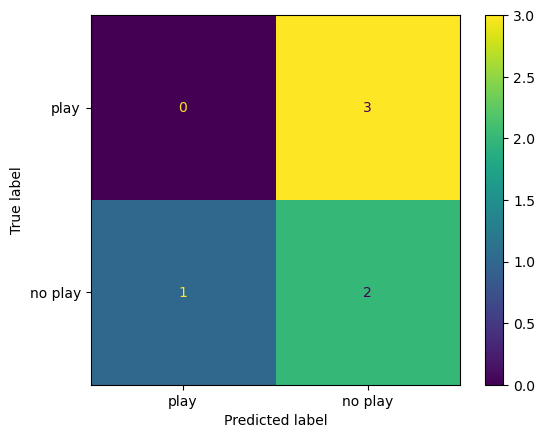

In [10]:
import matplotlib.pyplot as plt
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['play', 'no play'])

cm_display.plot()
plt.show()

In [11]:
from sklearn.neighbors import KNeighborsClassifier

#Create a KNN Classifier
KNN_model = KNeighborsClassifier(n_neighbors=3)
KNN_model.fit(X_train,y_train)

Y_Predict_KNN = KNN_model.predict(X_test)
print("KNN Accuracy:",metrics.accuracy_score(y_test, Y_Predict_KNN))

KNN Accuracy: 0.6666666666666666


### 2.ให้นำ model ที่ดีที่สุดที่ได้จากข้อ 1 มาใช้กับชุดข้อมูล new data เพื่อ classify ว่า ชุดข้อมูลใหม่ จะเล่น tennis หรือไม่เล่น tennis ข้อมูล new data ประกอบไปด้วย

| outlook | temperature | humidity | windy | play  |
| :------:|   :------:  | :-------:| :----:|:-----:|
|  sunny  |    hot      |    high  | strong|  ??   |
|overcast |    hot      |    normal| weak|  ??   |
|  rainy  |   cool      |    normal| strong|  ??   |
|  sunny  |    mild     |    high  | strong|  ??   |
|  rainy  |    mild     |    normal| weak|  ??   |

In [13]:
predicted= Gaussian_NB.predict([[2,1,0,0],[0,1,1,1],[1,0,1,0],[2,2,0,0],[1,2,1,1] ]) 
print("Predicted Value:", predicted)


Predicted Value: ['yes' 'yes' 'yes' 'no' 'yes']
